# Chapter 9: Regression and Prediction


In this notebook, we explore simple and multiple linear regression.

We will study:

- scatterplots and regression lines
- slope and intercept
- prediction
- residuals
- prediction error
- R-squared
- overfitting
- training and testing data
- multiple regression
- regularization with Ridge and Lasso


## Simple Linear Regression


Simple linear regression uses one predictor variable to predict one response variable.

Here, we use temperature to predict electricity demand.


In [1]:
# Temperature and electricity demand example

temperature <- c(
  2, 5, 7, 10, 12,
  15, 18, 20, 22,
  25, 27, 30, 32,
  35, 38
)

demand <- c(
  230, 250, 265, 290, 310,
  330, 360, 370, 390,
  410, 430, 455, 470,
  495, 510
)

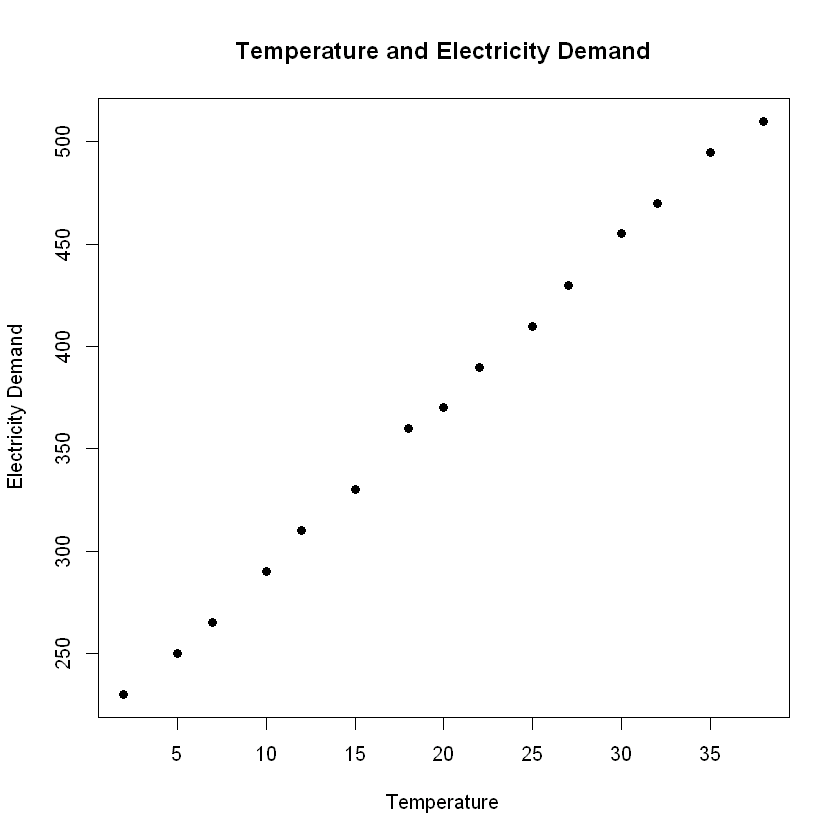

In [2]:
# Visualize the relationship

plot(
  temperature, demand,
  main = "Temperature and Electricity Demand",
  xlab = "Temperature",
  ylab = "Electricity Demand",
  pch = 19
)

In [3]:
# Create a data frame for regression

electricity_data <- data.frame(
  temperature = temperature,
  demand = demand
)

In [4]:
# Create and train the regression model

model <- lm(demand ~ temperature, data = electricity_data)

In [5]:
# Intercept and slope

cat("Intercept:", round(coef(model)[1], 2), "\n")
cat("Slope:", round(coef(model)[2], 2), "\n")

Intercept: 211.64 
Slope: 8.02 


In [6]:
# Predicted values

predictions <- predict(model, newdata = electricity_data)

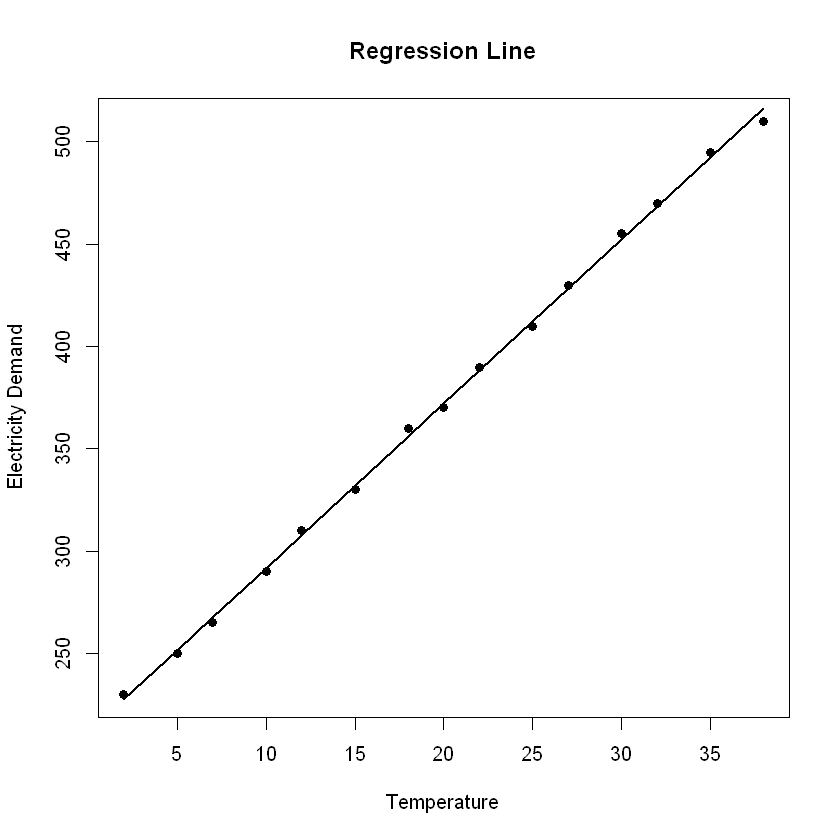

In [7]:
# Visualize the fitted regression line

plot(
  temperature, demand,
  main = "Regression Line",
  xlab = "Temperature",
  ylab = "Electricity Demand",
  pch = 19
)

lines(temperature, predictions, lwd = 2)

## Making Predictions

In [8]:
# Predict electricity demand at 28 degrees

new_data <- data.frame(temperature = 28)

predicted_value <- predict(model, newdata = new_data)

cat("Predicted demand:", round(predicted_value, 2), "\n")

Predicted demand: 436.24 


## Residuals

In [9]:
# Residuals measure prediction errors

residuals <- demand - predictions

print(head(residuals, 5))

        1         2         3         4         5 
 2.315723 -1.748485 -2.791289 -1.855497  2.101699 


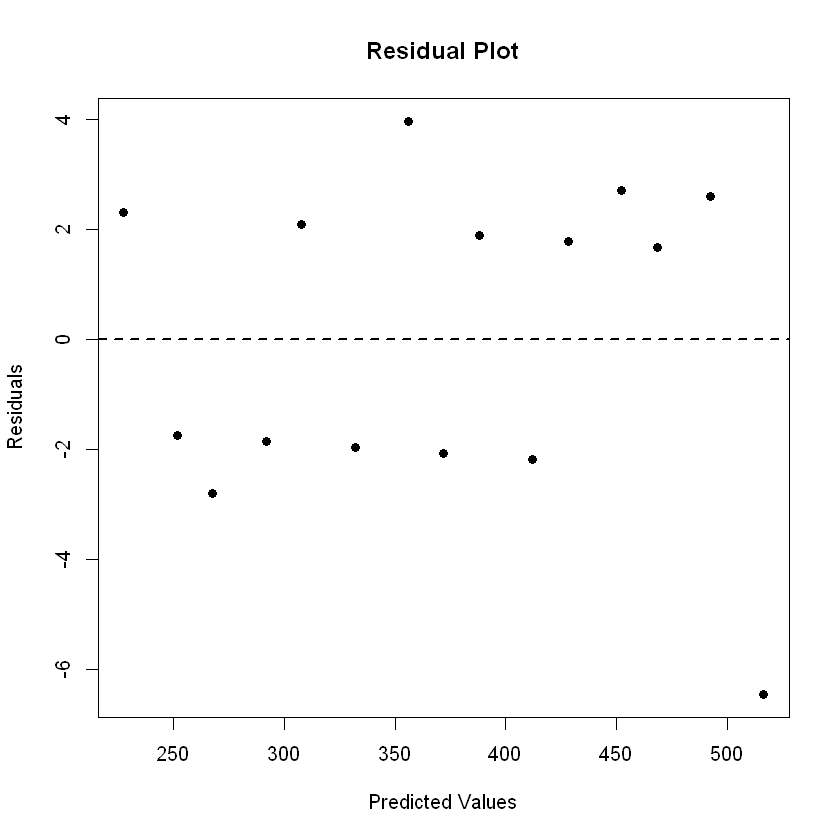

In [10]:
# Residual plot

plot(
  predictions, residuals,
  main = "Residual Plot",
  xlab = "Predicted Values",
  ylab = "Residuals",
  pch = 19
)

abline(h = 0, lty = 2, lwd = 2)

## Measuring Prediction Error

In [11]:
# Mean Absolute Error

mae <- mean(abs(demand - predictions))

cat("MAE:", round(mae, 2), "\n")

MAE: 2.54 


In [12]:
# Mean Squared Error

mse <- mean((demand - predictions)^2)

cat("MSE:", round(mse, 2), "\n")

MSE: 7.87 


In [13]:
# Root Mean Squared Error

rmse <- sqrt(mse)

cat("RMSE:", round(rmse, 2), "\n")

RMSE: 2.81 


## R-Squared

In [14]:
# R-squared measures how much variability
# is explained by the model.

r_squared <- summary(model)$r.squared

cat("R-squared:", round(r_squared, 3), "\n")

R-squared: 0.999 


## Training and Testing Data


To check whether a model generalizes well, we split the data into:

- training data: used to fit the model
- testing data: used to evaluate the model on unseen data


In [15]:
# Split the data into training and testing sets

set.seed(1)

n <- nrow(electricity_data)
test_index <- sample(1:n, size = ceiling(0.3 * n))

test_data <- electricity_data[test_index, ]
train_data <- electricity_data[-test_index, ]

In [16]:
# Train the model using only the training data

model <- lm(demand ~ temperature, data = train_data)

In [17]:
# Predictions on testing data

test_predictions <- predict(model, newdata = test_data)

In [18]:
# Evaluate prediction error on testing data

test_rmse <- sqrt(mean((test_data$demand - test_predictions)^2))

cat("Testing RMSE:", round(test_rmse, 2), "\n")

Testing RMSE: 2.79 


# Multiple Linear Regression


Multiple linear regression uses several predictor variables at the same time.

Here, we use house size, bedrooms, and age to predict house price.


In [19]:
# House price example

house_data <- data.frame(
  size = c(1200, 1500, 1800, 2000, 2300),
  bedrooms = c(2, 3, 3, 4, 4),
  age = c(20, 15, 12, 8, 5),
  price = c(250, 320, 360, 400, 460)
)

house_data

size,bedrooms,age,price
<dbl>,<dbl>,<dbl>,<dbl>
1200,2,20,250
1500,3,15,320
1800,3,12,360
2000,4,8,400
2300,4,5,460


In [20]:
# Predictor variables and response variable

# In R, the model formula specifies predictors and response directly.

In [21]:
# Train the multiple regression model

model <- lm(price ~ size + bedrooms,
            data = house_data)

In [22]:
# Regression coefficients

cat("Intercept:", round(coef(model)[1], 2), "\n\n")

cat("Coefficients:\n")

for (name in names(coef(model))[-1]) {
  cat(name, ":", round(coef(model)[name], 2), "\n")
}

Intercept: 32.2 

Coefficients:
size : 0.17 
bedrooms : 10.87 


In [23]:
# New house information

new_house <- data.frame(
    size = 1900,
    bedrooms = 3
)

predicted_price <- predict(model, newdata = new_house)

cat("Predicted price:", round(predicted_price, 2), "\n")

Predicted price: 378.98 


## Multicollinearity

In [24]:
# Correlation between predictor variables

predictors <- house_data[, c("size", "bedrooms", "age")]

cor(predictors)

,size,bedrooms,age
size,1.0000000,0.9359879,-0.9949584
bedrooms,0.9359879,1.0000000,-0.9665739
age,-0.9949584,-0.9665739,1.0000000


## Feature Selection

In [25]:
# Sometimes simpler models perform better.

cat("Good models balance simplicity and accuracy.\n")

Good models balance simplicity and accuracy.


# Appendix E: Regularization and Modern Predictive Modeling


Regularization helps control model complexity.

In this appendix, we will see how Ridge and Lasso regression behave differently from ordinary linear regression.


## Why Scaling Matters

In [26]:
# Variables on very different scales

scale_data <- data.frame(
  income = c(40000, 50000, 60000, 70000),
  age = c(20, 25, 30, 35)
)

scale_data

income,age
<dbl>,<dbl>
40000,20
50000,25
60000,30
70000,35


In [27]:
# Standardization gives a variable mean 0
# and standard deviation 1.

scaled_income <- as.numeric(scale(scale_data$income))

print(scaled_income)

[1] -1.1618950 -0.3872983  0.3872983  1.1618950


## Cyclical Variables

In [28]:
# Hours in a day

hours <- c(0, 6, 12, 18, 23)

In [29]:
# Sine transformation

hour_sin <- sin(2 * pi * hours / 24)

print(hour_sin)

[1]  0.000000e+00  1.000000e+00  1.224606e-16 -1.000000e+00 -2.588190e-01


In [30]:
# Cosine transformation

hour_cos <- cos(2 * pi * hours / 24)

print(hour_cos)

[1]  1.000000e+00  6.123032e-17 -1.000000e+00 -1.836910e-16  9.659258e-01


## A Dataset for Regularization


To see the effect of Ridge and Lasso clearly, we create a dataset with:

- useful predictors
- correlated predictors
- one mostly useless predictor

This helps us see why regularization can be useful.


In [31]:
# House price dataset with one weak predictor

regularization_data <- data.frame(
  size = c(1200, 1500, 1800, 2000, 2300, 2500, 2700, 3000),

  # Bedrooms is related to size
  bedrooms = c(2, 3, 3, 4, 4, 5, 5, 6),

  # Age is useful because newer houses tend to be more expensive
  age = c(20, 15, 12, 8, 5, 4, 3, 2),

  # This variable is mostly noise in this example
  coffee_shops = c(3, 8, 2, 7, 5, 1, 9, 4),

  price = c(250, 320, 360, 400, 460, 500, 540, 600)
)

regularization_data

size,bedrooms,age,coffee_shops,price
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1200,2,20,3,250
1500,3,15,8,320
1800,3,12,2,360
2000,4,8,7,400
2300,4,5,5,460
2500,5,4,1,500
2700,5,3,9,540
3000,6,2,4,600


In [32]:
# Predictor variables and response variable

X <- regularization_data[, c("size", "bedrooms", "age", "coffee_shops")]
y <- regularization_data$price

In [33]:
# Correlation between predictors

# Notice that size and bedrooms are highly related.
# This can make ordinary regression coefficients less stable.

cor(X)

,size,bedrooms,age,coffee_shops
size,1.00000000,0.97809662,-0.97088313,0.05017926
bedrooms,0.97809662,1.00000000,-0.94623488,0.07524435
age,-0.97088313,-0.94623488,1.00000000,-0.09440202
coffee_shops,0.05017926,0.07524435,-0.09440202,1.00000000


## Scaling Before Regularization

In [34]:
# Ridge and Lasso are affected by the scale of variables.
# Therefore, we standardize the predictors first.

X_scaled <- scale(X)

# Keep the standardized predictors in a data frame
X_scaled_df <- as.data.frame(X_scaled)
X_scaled_df$price <- y

## Ordinary Linear Regression

In [35]:
# Ordinary regression does not penalize large coefficients.

linear_model <- lm(price ~ size + bedrooms + age + coffee_shops,
                   data = X_scaled_df)

In [36]:
# Ordinary regression coefficients

cat("Ordinary Linear Regression Coefficients\n")

ordinary_coefs <- coef(linear_model)[-1]

for (name in names(ordinary_coefs)) {
  cat(name, ":", round(ordinary_coefs[name], 2), "\n")
}

Ordinary Linear Regression Coefficients
size : 114.77 
bedrooms : 11.4 
age : 8.65 
coffee_shops : 2.51 


## Ridge Regression

In [37]:
# Ridge regression shrinks coefficients toward zero.
# Here we use a simple closed-form ridge calculation.

ridge_alpha <- 10

X_matrix <- as.matrix(X_scaled)
y_centered <- y - mean(y)

ridge_coefs <- solve(
  t(X_matrix) %*% X_matrix + ridge_alpha * diag(ncol(X_matrix))
) %*% t(X_matrix) %*% y_centered

ridge_coefs <- as.vector(ridge_coefs)
names(ridge_coefs) <- colnames(X_matrix)

In [38]:
# Ridge coefficients

cat("Ridge Regression Coefficients\n")

for (name in names(ridge_coefs)) {
  cat(name, ":", round(ridge_coefs[name], 2), "\n")
}

Ridge Regression Coefficients
size : 27.54 
bedrooms : 26.58 
age : -25.45 
coffee_shops : 1.04 



Ridge usually keeps all predictors in the model, but it reduces the size of the coefficients.


## Lasso Regression

In [39]:
# Lasso regression can shrink some coefficients
# all the way to zero.
#
# To keep this notebook simple and package-free, we use a basic
# coordinate descent implementation for standardized predictors.

soft_threshold <- function(z, gamma) {
  sign(z) * pmax(abs(z) - gamma, 0)
}

lasso_alpha <- 10

X_matrix <- as.matrix(X_scaled)
y_centered <- y - mean(y)

lasso_coefs <- rep(0, ncol(X_matrix))

for (iteration in 1:1000) {
  for (j in 1:ncol(X_matrix)) {
    residual_j <- y_centered - X_matrix[, -j, drop = FALSE] %*% lasso_coefs[-j]
    rho <- sum(X_matrix[, j] * residual_j)
    lasso_coefs[j] <- soft_threshold(rho, lasso_alpha) / sum(X_matrix[, j]^2)
  }
}

names(lasso_coefs) <- colnames(X_matrix)

In [40]:
# Lasso coefficients

cat("Lasso Regression Coefficients\n")

for (name in names(lasso_coefs)) {
  cat(name, ":", round(lasso_coefs[name], 2), "\n")
}

Lasso Regression Coefficients
size : 104.02 
bedrooms : 12.43 
age : 0 
coffee_shops : 0.73 



Lasso may set weak predictor coefficients to zero.

This means Lasso can act as a simple feature-selection method.


## Comparing the Coefficients

In [41]:
# Put all coefficients into one table

comparison <- data.frame(
  Predictor = colnames(X_matrix),
  Ordinary_Regression = as.numeric(ordinary_coefs),
  Ridge_Regression = as.numeric(ridge_coefs),
  Lasso_Regression = as.numeric(lasso_coefs)
)

comparison

Predictor,Ordinary_Regression,Ridge_Regression,Lasso_Regression
<chr>,<dbl>,<dbl>,<dbl>
size,114.767533,27.539146,104.0179378
bedrooms,11.401855,26.583220,12.4324743
age,8.654476,-25.450308,0.0000000
coffee_shops,2.512580,1.040844,0.7288669


In [42]:
# Round the table for easier reading

round(comparison[, -1], 2)

Ordinary_Regression,Ridge_Regression,Lasso_Regression
<dbl>,<dbl>,<dbl>
114.77,27.54,104.02
11.40,26.58,12.43
8.65,-25.45,0.00
2.51,1.04,0.73



This table makes the difference easier to see:

- Ordinary regression freely estimates the coefficients.
- Ridge shrinks the coefficients but usually keeps all predictors.
- Lasso may shrink weak predictors to zero.


## Comparing Predictions

In [43]:
# Split the data into training and testing sets

set.seed(1)

n <- nrow(X_scaled_df)
test_index <- sample(1:n, size = ceiling(0.3 * n))

train_data <- X_scaled_df[-test_index, ]
test_data <- X_scaled_df[test_index, ]

In [44]:
# Compare predictions from the three models

# Ordinary linear regression

linear_model <- lm(price ~ size + bedrooms + age + coffee_shops,
                   data = train_data)

ordinary_predictions <- predict(linear_model, newdata = test_data)

# Ridge regression

X_train <- as.matrix(train_data[, c("size", "bedrooms", "age", "coffee_shops")])
y_train <- train_data$price

X_test <- as.matrix(test_data[, c("size", "bedrooms", "age", "coffee_shops")])
y_test <- test_data$price

y_train_centered <- y_train - mean(y_train)

ridge_coefs_train <- solve(
  t(X_train) %*% X_train + ridge_alpha * diag(ncol(X_train))
) %*% t(X_train) %*% y_train_centered

ridge_predictions <- as.vector(X_test %*% ridge_coefs_train + mean(y_train))

# Lasso regression

lasso_coefs_train <- rep(0, ncol(X_train))

for (iteration in 1:1000) {
  for (j in 1:ncol(X_train)) {
    residual_j <- y_train_centered - X_train[, -j, drop = FALSE] %*% lasso_coefs_train[-j]
    rho <- sum(X_train[, j] * residual_j)
    lasso_coefs_train[j] <- soft_threshold(rho, lasso_alpha) / sum(X_train[, j]^2)
  }
}

lasso_predictions <- as.vector(X_test %*% lasso_coefs_train + mean(y_train))

In [45]:
# Compare testing RMSE values

ordinary_rmse <- sqrt(mean((y_test - ordinary_predictions)^2))
ridge_rmse <- sqrt(mean((y_test - ridge_predictions)^2))
lasso_rmse <- sqrt(mean((y_test - lasso_predictions)^2))

cat("Ordinary Regression RMSE:", round(ordinary_rmse, 2), "\n")
cat("Ridge Regression RMSE:", round(ridge_rmse, 2), "\n")
cat("Lasso Regression RMSE:", round(lasso_rmse, 2), "\n")

Ordinary Regression RMSE: 9.58 
Ridge Regression RMSE: 85.38 
Lasso Regression RMSE: 13.86 



Regularized models may have slightly larger training error.

This is normal because they are intentionally making the model simpler.

The goal is not always to fit the training data perfectly, but to build a model that generalizes better to new data.


In [46]:
# In this small example, ordinary regression performs best.
# This can happen when the dataset is very small and the relationships are relatively clean.

# Ridge and Lasso become more useful when:
# - datasets are larger,
# - predictors are highly correlated,
# - many variables are included,
# - or overfitting becomes a serious problem.

cat("Regularization is most helpful in more complex modeling situations.\n")

Regularization is most helpful in more complex modeling situations.
